In [2]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from keras.models import Sequential
from keras.layers import Dense
from mlxtend.plotting import plot_decision_regions




I0000 00:00:1789539192.700432    2317 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789539210.575069    2317 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789539225.791766    2317 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


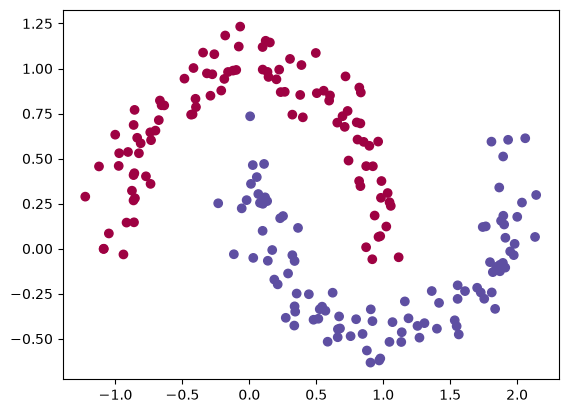

In [3]:
x,y = make_moons(n_samples=200, noise=0.1, random_state=42)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.Spectral)

<h1>Case 1- Initializing all Weights and Bias with 0</h1>

<h3>a. ReLU</h3>

In [4]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.get_weights()
new_weights = [np.zeros_like(w) for w in model.get_weights()]
model.set_weights(new_weights)
model.get_weights()





/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789539242.729104    2317 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [5]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4600 - loss: 0.6932
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4500 - loss: 0.6933 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4700 - loss: 0.6932 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4100 - loss: 0.6932 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4200 - loss: 0.6932 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4500 - loss: 0.6932 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

In [6]:
#No Change in weight seen
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([-0.00087412], dtype=float32)]

In [7]:
class KerasClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_prob = self.model.predict(X)
        return (y_prob > 0.5).astype(int).flatten()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 829us/step


<Axes: >

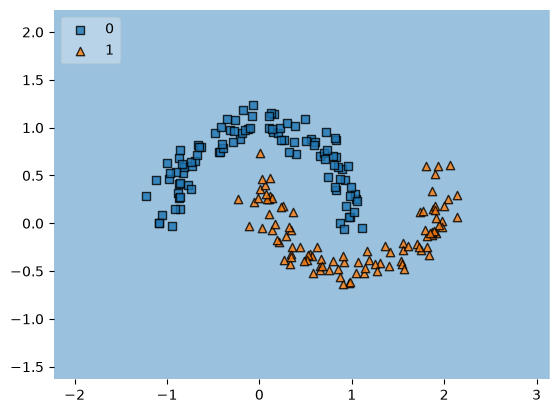

In [8]:
#this shows a very poor decision boundary
pred_model = KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf=pred_model, legend=2)

<h3>b. Tanh</3>

In [9]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))   

new_weights = [np.zeros_like(w) for w in model.get_weights()]
model.set_weights(new_weights)
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [10]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5000 - loss: 0.6932   
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4500 - loss: 0.6932 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4400 - loss: 0.6932 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5100 - loss: 0.6932 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

In [11]:
#No update in weight
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.00039151], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 816us/step


<Axes: >

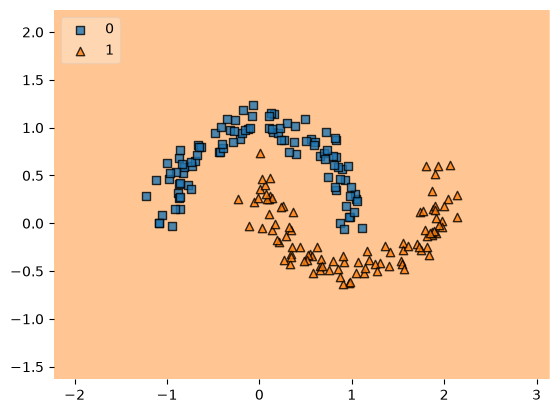

In [12]:
pred_model = KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf=pred_model, legend=2)

<h3>c. Sigmoid</h3>

In [13]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))   

new_weights = [np.zeros_like(w) for w in model.get_weights()]
model.set_weights(new_weights)
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [14]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)

Epoch 1/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5000 - loss: 0.6933   
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4950 - loss: 0.6932 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.6932 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.6934 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6927 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6923 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6920 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6913 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6893 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.6878 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [15]:
#All the weights in a layer are exactly the smae 
#Give a linear model
model.get_weights()

[array([[-1.357644, -1.357644, -1.357644, -1.357644, -1.357644, -1.357644,
         -1.357644, -1.357644, -1.357644, -1.357644],
        [ 2.264921,  2.264921,  2.264921,  2.264921,  2.264921,  2.264921,
          2.264921,  2.264921,  2.264921,  2.264921]], dtype=float32),
 array([-0.8647909 , -0.8647909 , -0.8647909 , -0.8647909 , -0.8647909 ,
        -0.8647909 , -0.86479104, -0.86479104, -0.86479104, -0.86479104],
       dtype=float32),
 array([[-0.43891805],
        [-0.43891805],
        [-0.43891805],
        [-0.43891805],
        [-0.43891805],
        [-0.43891805],
        [-0.43891805],
        [-0.43891805],
        [-0.43891805],
        [-0.43891805]], dtype=float32),
 array([1.0932076], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 863us/step


<Axes: >

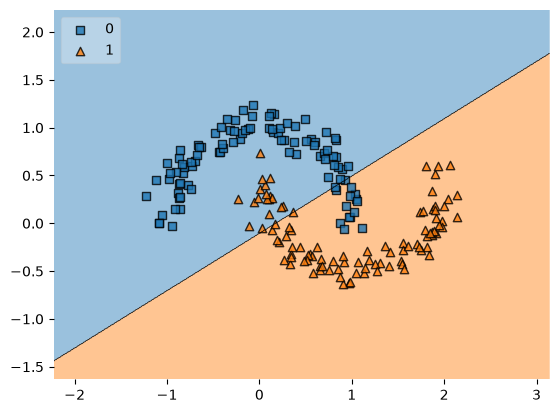

In [16]:
#On plottig we see a clear lie proving that the model cant capture non-linear relationship i.e. its linear
pred_model = KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf=pred_model, legend=2)

<h1>Case 2- Initializing all Weights and Bias with same number</h1>

<h3>a. ReLU</h3>

In [17]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='relu'))
model.add(Dense(1,activation='sigmoid'))

#initialize all weights and biases with 0.5
new_weights = [np.ones_like(w)*0.5 for w in model.get_weights()]
model.set_weights(new_weights)
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [18]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)

Epoch 1/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5000 - loss: 2.2771   
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 2.1188 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 1.9835 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.8455 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.7254 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.6139 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.5113 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.4159 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.3299 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.2509 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.1801 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [19]:
#Weights in a layer are same => linear model
model.get_weights()

[array([[ 0.42619863,  0.42619863,  0.42619863,  0.42619863,  0.42619863,
          0.42619863,  0.42619863,  0.42619863,  0.42619863,  0.42619863],
        [-0.3850435 , -0.3850435 , -0.3850435 , -0.3850435 , -0.3850435 ,
         -0.3850435 , -0.3850435 , -0.3850435 , -0.3850435 , -0.3850435 ]],
       dtype=float32),
 array([0.17496091, 0.17496091, 0.17496091, 0.17496091, 0.17496091,
        0.17496091, 0.17496091, 0.17496091, 0.17496091, 0.17496091],
       dtype=float32),
 array([[0.27776152],
        [0.27776152],
        [0.27776152],
        [0.27776152],
        [0.27776152],
        [0.27776152],
        [0.27776152],
        [0.27776152],
        [0.27776152],
        [0.27776152]], dtype=float32),
 array([-0.5634976], dtype=float32)]

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 7:30 47ms/step

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 888us/step


<Axes: >

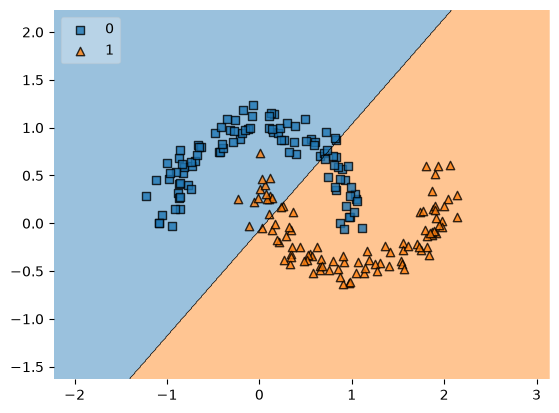

In [20]:
#This is again a linear model
pred_model=KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf = pred_model, legend=2)

<h3>b. Tanh</h3>

In [21]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

#initialize all weights and biases with 0.5
new_weights = [np.ones_like(w)*0.5 for w in model.get_weights()]
model.set_weights(new_weights)
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [22]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)
#Weights in a layer are same => linear model
model.get_weights()

Epoch 1/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5000 - loss: 1.8015   
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.7020 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5100 - loss: 1.6068 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5100 - loss: 1.5138 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5250 - loss: 1.4330 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5250 - loss: 1.3483 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5250 - loss: 1.2737 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5300 - loss: 1.2065 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5350 - loss: 1.1430 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5400 - loss: 1.0845 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5550 - loss: 1.0312 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

[array([[ 0.34541565,  0.34541565,  0.34541565,  0.34541565,  0.34541565,
          0.34541565,  0.34541565,  0.34541565,  0.34541565,  0.34541565],
        [-0.67814344, -0.67814344, -0.67814344, -0.67814344, -0.67814344,
         -0.67814344, -0.67814344, -0.67814344, -0.67814344, -0.67814344]],
       dtype=float32),
 array([-0.00775822, -0.00775822, -0.00775822, -0.00775822, -0.00775822,
        -0.00775822, -0.00775822, -0.00775822, -0.00775822, -0.00775822],
       dtype=float32),
 array([[0.45157698],
        [0.45157698],
        [0.45157698],
        [0.45157698],
        [0.45157698],
        [0.45157698],
        [0.45157698],
        [0.45157698],
        [0.45157698],
        [0.45157698]], dtype=float32),
 array([-0.11691673], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 767us/step


<Axes: >

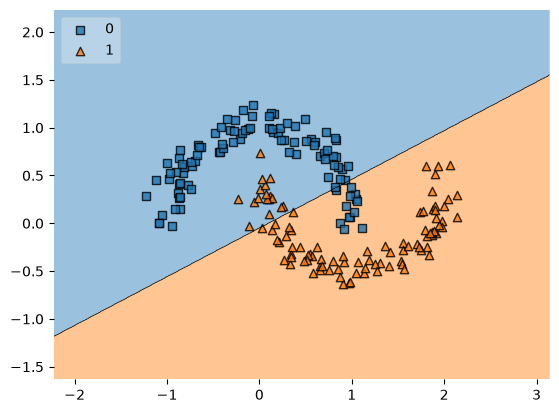

In [23]:
#This is again a linear model
pred_model=KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf = pred_model, legend=2)

<h3>c. Sigmoid</h3>

In [24]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

#initialize all weights and biases with 0.5
new_weights = [np.ones_like(w)*0.5 for w in model.get_weights()]
model.set_weights(new_weights)
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [25]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)
#Weights in a layer are same => linear model
model.get_weights()

Epoch 1/100
 1/20 ━━━━━━━━━━━━━━━━━━━━ 10s 561ms/step - accuracy: 0.5000 - loss: 1.8798

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5000 - loss: 1.9522 
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.8694 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.7861 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.7067 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.6302 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.5534 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 1.4828 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 1.4139 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.3481 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 1.2853 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 1.2267 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 

[array([[ 1.1242982 ,  1.1242982 ,  1.1242982 ,  1.1242982 ,  1.1242982 ,
          1.1242982 ,  1.1242982 ,  1.1242982 ,  1.1242982 ,  1.1242982 ],
        [-0.27448803, -0.27448803, -0.27448803, -0.27448803, -0.27448803,
         -0.27448803, -0.27448788, -0.27448788, -0.27448788, -0.27448788]],
       dtype=float32),
 array([0.02461613, 0.02461613, 0.02461613, 0.02461613, 0.02461613,
        0.02461613, 0.02461619, 0.02461619, 0.02461619, 0.02461619],
       dtype=float32),
 array([[0.1032214 ],
        [0.1032214 ],
        [0.1032214 ],
        [0.1032214 ],
        [0.1032214 ],
        [0.1032214 ],
        [0.10322136],
        [0.10322136],
        [0.10322136],
        [0.10322136]], dtype=float32),
 array([-0.31659946], dtype=float32)]

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 8:38 54ms/step

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 797us/step


<Axes: >

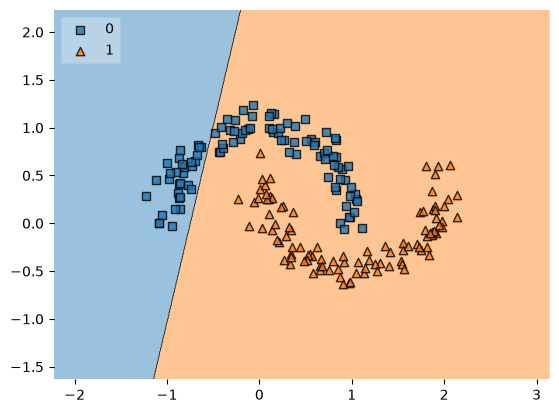

In [26]:
#This is again a linear model
pred_model=KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf = pred_model, legend=2)

<h1>Xavier/Glorat and He Initializing</h1>

<h3>Doing Manually</h3>

In [35]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

#initialize all weights and biases with 0.5
initial_weigts = model.get_weights()
model.summary()

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
initial_weigts[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weigts[1] = np.zeros(model.get_weights()[1].shape)
initial_weigts[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weigts[3] = np.zeros(model.get_weights()[3].shape)
initial_weigts[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weigts[5] = np.zeros(model.get_weights()[5].shape)
initial_weigts[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weigts[7] = np.zeros(model.get_weights()[7].shape)
initial_weigts[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weigts[9] = np.zeros(model.get_weights()[9].shape)
model.set_weights(initial_weigts)
model.get_weights()

[array([[-0.6706371 , -0.65123177,  0.6639969 ,  0.2639603 , -0.4152979 ,
         -0.54284316, -0.4427462 ,  0.78263324,  0.40146452,  1.2401708 ],
        [ 0.14974287, -0.34259924,  0.3400261 , -1.2469975 , -0.9866252 ,
          0.7771361 ,  0.34608164,  0.07648869, -0.9272029 ,  0.7958646 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.5815718 , -0.0394211 ,  0.04788687, -0.05697575, -0.46747628,
          0.3000105 ,  0.43300378, -0.0793469 , -0.168038  ,  0.1199579 ],
        [ 0.38091663, -0.3473993 , -0.3601323 , -0.8552199 ,  0.42772326,
         -0.10866644, -0.10671905,  0.3463    , -0.1931725 , -0.04887507],
        [-0.04739868,  0.31488308, -0.01085523, -0.39527163,  0.00313149,
          0.2243775 ,  0.19855937, -0.18193878,  0.36641008,  0.18400255],
        [-0.12287147,  0.3027309 ,  0.08450893, -0.17595546,  0.16021688,
         -0.04650021,  0.340837  , -0.03597044, -0.43668917, -0.5474395 ],
        [ 0.11005

In [37]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)
model.get_weights()

Epoch 1/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3500 - loss: 0.7756
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6450 - loss: 0.6583 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7300 - loss: 0.5807 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7700 - loss: 0.5185 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8200 - loss: 0.4584 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8300 - loss: 0.4133 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8450 - loss: 0.3800 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8500 - loss: 0.3563 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 0.3402 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8700 - loss: 0.3265 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8750 - loss: 0.3184 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0

[array([[-0.42355523, -1.2720915 ,  1.0232642 ,  0.2830159 , -0.37523416,
         -0.6808979 , -0.907932  ,  0.7159855 ,  0.4665355 ,  1.8175447 ],
        [ 0.2487686 , -0.22012141,  0.46570066, -1.1136343 , -0.7327069 ,
          0.43025234,  0.31691328, -0.14715713, -0.7883082 ,  1.0333948 ]],
       dtype=float32),
 array([-0.05928288,  0.15441348, -0.20118722, -0.26442242,  0.27753976,
         0.44452825,  0.16520603, -0.18893167,  0.1152764 ,  0.57826006],
       dtype=float32),
 array([[-3.78679693e-01,  7.23707452e-02,  2.12211370e-01,
         -3.00701469e-01, -2.81364441e-01,  3.87177825e-01,
          3.07798922e-01, -1.99366048e-01, -5.29536426e-01,
          9.21349302e-02],
        [ 7.77200818e-01, -4.24432427e-01, -4.03955936e-01,
         -9.96052742e-01,  3.48595738e-01, -1.72845647e-01,
         -1.03490755e-01,  4.39966798e-01, -6.04208946e-01,
         -2.26060599e-01],
        [-5.63917220e-01,  3.13288152e-01,  5.02124876e-02,
         -3.56851399e-01,  2.37583

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 830us/step


<Axes: >

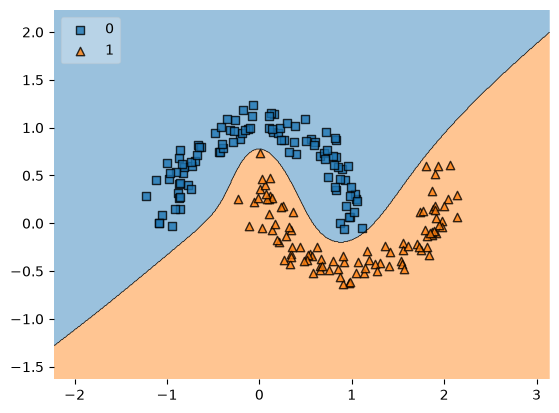

In [38]:
pred_model=KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf = pred_model, legend=2)

<h2>Glorot Uniform- Default</h2>
<p>Draws weights from a uniform distribution. Best used with sigmoid, tanh, or linear activation functions<br>
Draws samples from a uniform distribution within [-limit, limit] where limit = sqrt(6/(in + out))<p>

In [52]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='tanh', kernel_initializer='glorot_uniform'))
model.add(Dense(10, activation='tanh', kernel_initializer='glorot_uniform'))
model.add(Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform'))
#model.get_weights()



Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6200 - loss: 0.6783   
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6950 - loss: 0.6262 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7400 - loss: 0.5837 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7450 - loss: 0.5455 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7500 - loss: 0.5106
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7650 - loss: 0.4804 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 0.4503 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7950 - loss: 0.4257 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4023 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8150 - loss: 0.3840 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8200 - loss: 0.3686 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

<Axes: >

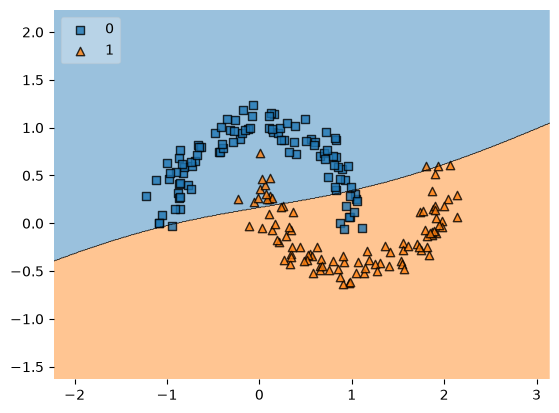

In [53]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)
#model.get_weights()

pred_model=KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf = pred_model, legend=2)

<h2>Glorot Normal</h2>
<p>Draws weights from a normal (Gaussian) distribution scaled to the number of input and output units.<br>
Draws samples from a truncated normal distribution centered on 0 with a standard deviation (σ)<br>
where σ = sqrt(2/(in +out))</p>


In [56]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='tanh', kernel_initializer='glorot_normal'))
model.add(Dense(10, activation='tanh', kernel_initializer='glorot_normal'))
model.add(Dense(1, activation='sigmoid', kernel_initializer='glorot_normal'))
model.get_weights()

[array([[ 0.6644609 ,  0.8021438 , -0.582204  , -0.4252488 , -0.14057906,
         -0.51801425,  0.55466145, -0.78997076, -0.41124773, -0.51031667],
        [ 0.704328  ,  0.10191695, -0.3228002 ,  0.09134726, -0.81856275,
          0.6979197 ,  0.20835644, -0.127775  ,  0.39776373,  0.5960548 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.5256564 ,  0.22348276,  0.3721548 , -0.01913903, -0.13549763,
          0.37179974,  0.42479962,  0.16731529, -0.5075836 ,  0.2177838 ],
        [ 0.05310164, -0.3241684 , -0.34882677, -0.23996538, -0.27582085,
          0.32511777, -0.0026267 ,  0.09041197, -0.0272431 , -0.05458086],
        [ 0.5390397 , -0.00550608, -0.24272217,  0.19787852, -0.07965462,
          0.07284112,  0.12062433, -0.16311905, -0.08436663,  0.48044726],
        [ 0.533169  , -0.12803723, -0.15126847,  0.22934169, -0.2054744 ,
         -0.15790236, -0.52830976, -0.30503783, -0.41320977,  0.36381623],
        [ 0.42879

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6600 - loss: 0.6510   
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7150 - loss: 0.5884 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7400 - loss: 0.5402 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7650 - loss: 0.5028 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 0.4728 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7950 - loss: 0.4498 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8050 - loss: 0.4297 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8050 - loss: 0.4128 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8200 - loss: 0.3985 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.3857 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8300 - loss: 0.3746 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

<Axes: >

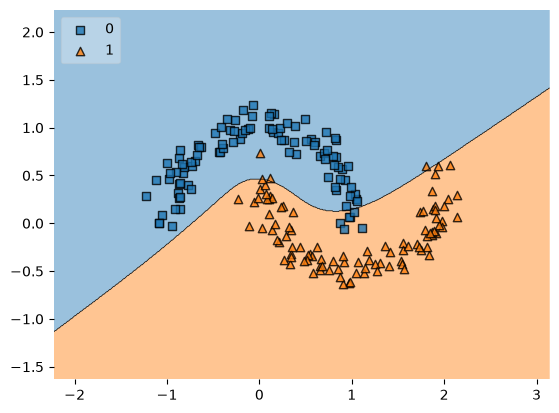

In [57]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)
#model.get_weights()

pred_model=KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf = pred_model, legend=2)

<h2>He Uniform</h2>
<p>Uses a uniform distribution tailored for ReLU activation functions.<br>
Draws samples from a uniform distribution within [-limit, limit]:<br>
where limit = sqrt(6/in)</p>



In [58]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(1, activation='sigmoid', kernel_initializer='he_uniform'))
model.get_weights()

[array([[ 1.1505984 ,  1.5656501 ,  1.1922611 , -0.44881976, -1.4601299 ,
         -0.2329377 , -0.59096396,  0.031726  ,  0.959165  ,  0.74583375],
        [ 0.74562347, -0.6368253 ,  0.7729124 ,  1.451291  ,  1.4070319 ,
         -0.51705325, -1.6462293 ,  0.8601936 , -0.32964802, -1.2880944 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.1470977 ,  0.00919533, -0.44911328,  0.76003647, -0.3508665 ,
         -0.10706538, -0.00473994,  0.34052324, -0.5383066 ,  0.6296332 ],
        [ 0.65053725, -0.7159017 ,  0.696159  ,  0.02291322,  0.00399458,
         -0.09419107, -0.5978053 ,  0.2601267 ,  0.07905871,  0.69517803],
        [ 0.7299378 , -0.14598042,  0.11487317,  0.35089195, -0.3474808 ,
          0.07539082,  0.5028111 ,  0.32794702, -0.16117221, -0.06426656],
        [ 0.12686598,  0.62712634, -0.64125586,  0.04413462,  0.23991036,
          0.03679049,  0.09366143,  0.4161055 , -0.07846278,  0.65964985],
        [-0.70859

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1950 - loss: 0.9396   
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1700 - loss: 0.8314 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3150 - loss: 0.7601 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5700 - loss: 0.7053 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7050 - loss: 0.6561 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7150 - loss: 0.6133 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7450 - loss: 0.5721 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7600 - loss: 0.5379 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7700 - loss: 0.5049 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7900 - loss: 0.4723 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8100 - loss: 0.4427 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

<Axes: >

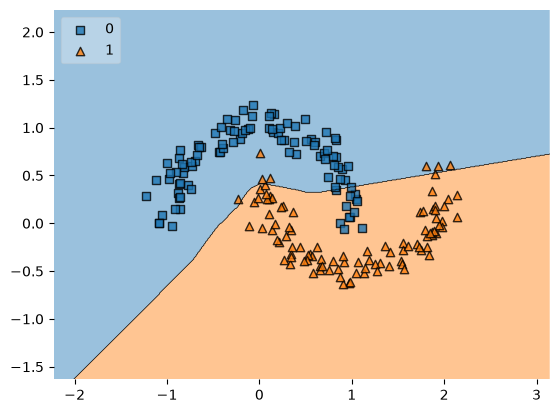

In [59]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)
#model.get_weights()

pred_model=KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf = pred_model, legend=2)

<h2>He Normal</h2>
<p>Uses a normal distribution tailored for ReLU activation functions.<br>
Draws samples from a truncated normal distribution centered on 0 with a standard deviation (σ):<br>
where σ = sqrt(2/in)</p>

In [60]:
model = Sequential()
model.add(Dense(10, input_dim=2, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(1, activation='sigmoid', kernel_initializer='he_normal'))
model.get_weights()

[array([[ 0.6156757 ,  0.7129387 , -1.060211  ,  0.39710423,  1.7719635 ,
          1.7937547 , -0.55079854,  0.0974478 ,  1.169299  , -0.6335851 ],
        [-1.9141039 , -1.6066133 , -0.97844696, -2.0657485 ,  0.2063077 ,
          1.3517051 ,  0.93036294,  1.4708655 , -1.7443955 , -1.2548181 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.69615144, -0.21757078, -0.58420855,  0.18382679,  0.21250339,
         -0.13622318,  0.26705408,  0.17404422, -0.031916  ,  0.3041761 ],
        [-0.02386563, -0.16973583,  0.27010602, -0.43120635, -0.40190858,
         -0.3711498 , -0.09461065,  0.260373  ,  0.9675725 , -0.27384737],
        [ 0.16829154, -0.23205192,  0.24029298,  0.11268783, -0.61571795,
         -0.14715278,  0.31629726, -0.5593857 ,  0.2697287 , -0.82962257],
        [-0.5075774 , -0.78439873, -0.68551326,  0.09663542,  1.0010895 ,
          0.9674899 ,  0.30243212, -0.4281598 , -0.2232117 ,  0.54400593],
        [ 0.36982

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6000 - loss: 0.6735   
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6750 - loss: 0.6357 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6950 - loss: 0.6069 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7050 - loss: 0.5818 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7200 - loss: 0.5580 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7700 - loss: 0.5351 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8350 - loss: 0.5123 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8550 - loss: 0.4889 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 0.4640 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8550 - loss: 0.4409 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8500 - loss: 0.4180 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

<Axes: >

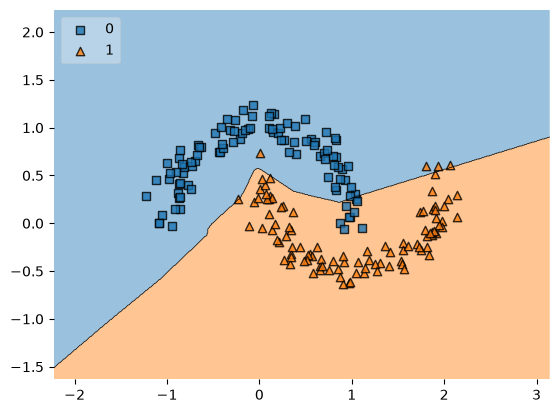

In [61]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, verbose=1)
#model.get_weights()

pred_model=KerasClassifier(model)
plot_decision_regions(x, y.flatten(), clf = pred_model, legend=2)